# Executive Summary: How This Dataset Was Built



This notebook turns 8 years of Virginia **statewide monthly** hospital-utilization aggregates into a **synthetic daily dataset** for one representative hospital, VCU Medical Center, broken out by 9 hospital sections. No patient-level or VCU-specific daily data exists — every daily and section-level figure here is a documented statistical estimate, not an observation.



| | |

|---|---|

| **Target hospital** | VCU Medical Center — 905 staffed beds |

| **Time range** | January 2017 – December 2024 |

| **Sections modeled** | Newborn, delivery, ED/non-ED non-elective, elective, COVID-19, influenza, other viral, ICU |

| **Output granularity** | Daily, per section |

| **Reproducibility** | Seeded random generation throughout |



---



## Source Data



- **Statewide monthly series** — occupied beds, ICU beds, and length-of-stay by admission type/diagnosis, from HCUP/AHRQ Virginia trend tables (2017–2024).

- **VCU-specific reference data** — 905 staffed beds, 247,208 annual patient days, 41,852 annual discharges, from the American Hospital Directory.



---



## Build Process



**1. Scale to one hospital**

Dividing the statewide total evenly by Virginia's 317 hospitals was rejected as unrepresentative — VCU is a large tertiary center, not an average-sized hospital. Instead, VCU's reference census (676.82 beds/day, 74.79% occupancy) was used to calibrate its share of the statewide total (5.45%), applied across every historical month to reconstruct a VCU-specific monthly census.



**2. Reconstruct daily values from monthly averages**

Daily values were generated with a seeded autoregressive (AR(1)) process that reproduces each month's known mean while adding realistic, correlated day-to-day variation.



**3. Split occupancy into 9 hospital sections**

ICU is treated as a peer section, not a diagnosis subset. The other 8 sections split the *non-ICU* remainder using each section's length-of-stay (LOS) as a proportional weight — the smallest defensible assumption, since no section-level admission counts exist.



**4. Model realistic daily dynamics (admissions/discharges turnover)**

Daily occupancy follows an explicit recurrence:



$$

\text{occupied}(t) = \text{occupied}(t-1) - \frac{\text{occupied}(t-1)}{\text{LOS}(t)} + \text{admissions}(t)

$$



Admissions are Poisson-distributed around the rate needed to sustain each month's target. Tomorrow's bed count genuinely depends on today's count and that section's *current* stay length — long-LOS sections are naturally "stickier" day to day than short-LOS sections.



**5. Correct two data-quality problems**



| Issue | Problem | Fix |

|---|---|---|

| COVID-19 gaps | No data pre-outbreak (correctly missing); 3 unavailable months at the end (Oct–Dec 2024) | Decay-to-floor curve fit to the post-peak trend, plus a calendar-month seasonal index for the winter uptick |

| December 2024 outlier | Statewide/ICU occupancy dropped far outside every other year's Nov→Dec pattern (z-scores ≈ -12) — a data-entry error, not a real decline | Corrected using the historical average Nov→Dec growth rate |



**6. Validate at every step**

Daily reconstruction matches monthly targets within ~0.02 bed; the 9 sections always sum exactly to the validated total census; corrected/estimated values were cross-checked against historical patterns before acceptance.



---



## What This Data Can and Cannot Support



**Can:** capacity/utilization trends, seasonality, section-level occupancy and turnover patterns, free-bed and admissions/discharges estimates for VCU, 2017–2024.



**Cannot:** real patient-level outcomes or true admission counts, ward-specific bed-pool constraints, or anything before 2017 or after December 2024 (2025–2026 forecasting is a separate, not-yet-built step).



Every assumption is documented in `data/assumptions.yaml` and `docs/occupied_beds_forecast_decisions.md`, including open questions still unresolved (e.g., no ICU-specific LOS can be derived from this dataset — it is mathematically identical to the hospital-wide average).


In [27]:


from datetime import date

number_of_hospitals = 317 #https://poidata.io/report/hospital/united-states/virginia
#https://hcup-us.ahrq.gov/reports/trendtables/summarytrendtables.jsp#over 
Average_number_of_occupied_beds_per_day = [
    11991, 12031, 11851, 11504, 11308, 11287, 11194, 11270,
    11434, 11377, 11380, 11271, 12353, 12128, 11556, 11480,
    11242, 11364, 11193, 11187, 11375, 11539, 11492, 11436,
    12191, 12275, 12231, 11788, 11740, 11601, 11555, 11624,
    11717, 11726, 11617, 11835, 12342, 12191, 10572, 9080,
    10464, 11049, 11302, 11469, 11601, 11766, 11745, 12108,
    12465, 12041, 11761, 11203, 11566, 11865, 11935, 12394,
    12814, 12543, 12206, 12473, 12851, 12380, 11742, 11637,
    11752, 12016, 11937, 11884, 11953, 11997, 12183, 12252,
    12507, 12253, 12041, 11824, 11955, 11918, 11921, 12008,
    11996, 12332, 12383, 12684, 13154, 12809, 12583, 12525,
    12300, 12224, 12195, 12293, 12462, 12318, 11970, 10037,
]

Dates_of_data = [
    date(year, month, 1)
    for year in range(2017, 2025)
    for month in range(1, 13)
]


average_daily_number_of_intesnive_beds = [
    1743, 1769, 1723, 1668, 1591, 1525, 1512, 1526,
    1560, 1567, 1579, 1580, 1771, 1733, 1665, 1662,
    1592, 1603, 1604, 1582, 1618, 1634, 1661, 1699,
    1812, 1860, 1829, 1708, 1703, 1686, 1616, 1620,
    1638, 1650, 1662, 1720, 1792, 1775, 1544, 1473,
    1664, 1664, 1674, 1717, 1666, 1623, 1654, 1802,
    1886, 1739, 1647, 1628, 1625, 1556, 1577, 1742,
    1849, 1784, 1706, 1812, 1880, 1748, 1567, 1402,
    1287, 1283, 1299, 1288, 1288, 1312, 1348, 1368,
    1389, 1359, 1325, 1303, 1279, 1263, 1262, 1253,
    1271, 1324, 1331, 1398, 1420, 1348, 1339, 1334,
    1271, 1300, 1285, 1293, 1292, 1283, 1244, 903,
]

minimum_daily_number_of_intensive_beds = [
    1266, 1333, 1273, 1200, 1171, 1086, 1082, 1105,
    1126, 1136, 1145, 1124, 1335, 1315, 1223, 1227,
    1142, 1184, 1169, 1157, 1184, 1210, 1180, 1270,
    1349, 1425, 1403, 1270, 1272, 1249, 1196, 1189,
    1219, 1239, 1215, 1244, 1367, 1328, 1005, 1031,
    1231, 1248, 1217, 1286, 1221, 1219, 1239, 1391,
    1481, 1304, 1229, 1224, 1215, 1155, 1175, 1306,
    1468, 1371, 1310, 1403, 1455, 1348, 1157, 927,
    947, 913, 939, 917, 892, 937, 984, 978,
    1016, 1010, 957, 927, 919, 907, 878, 901,
    900, 981, 961, 1018, 1027, 995, 959, 963,
    907, 922, 916, 943, 957, 931, 886, 7,
]

maximum_daily_number_of_intensive_beds = [
    2235, 2243, 2215, 2187, 2062, 1978, 2015, 1981,
    2010, 2033, 2037, 2048, 2231, 2183, 2164, 2107,
    2092, 2078, 2067, 2055, 2098, 2081, 2162, 2173,
    2289, 2355, 2276, 2202, 2189, 2190, 2118, 2101,
    2116, 2112, 2151, 2199, 2260, 2233, 2149, 1962,
    2111, 2083, 2121, 2142, 2114, 2063, 2109, 2274,
    2304, 2198, 2101, 2084, 2052, 2003, 2059, 2187,
    2268, 2213, 2152, 2273, 2314, 2175, 2025, 1962,
    1697, 1692, 1701, 1667, 1689, 1715, 1740, 1757,
    1812, 1778, 1744, 1708, 1707, 1672, 1642, 1638,
    1684, 1706, 1745, 1828, 1850, 1746, 1745, 1728,
    1677, 1693, 1699, 1694, 1668, 1659, 1625, 1528,
]

# same day discharge is 0 (measured in days)

newborn_wait_times = [
    2.05, 2.03, 2.03, 2.02, 2.04, 2.03, 2.08, 2.03,
    2.04, 2.05, 2.04, 2.03, 2.06, 2.07, 2.05, 2.03,
    2.01, 2.04, 2.06, 2.03, 2.04, 2.05, 2.03, 2.03,
    2.03, 2.07, 2.03, 2.02, 2.01, 2.02, 2.03, 2.02,
    2.03, 2.01, 2.01, 1.99, 2.02, 2.01, 1.89, 1.75,
    1.79, 1.79, 1.80, 1.82, 1.83, 1.83, 1.86, 1.83,
    1.82, 1.83, 1.82, 1.83, 1.84, 1.82, 1.86, 1.84,
    1.83, 1.84, 1.86, 1.83, 1.82, 1.82, 1.81, 1.84,
    1.82, 1.81, 1.83, 1.83, 1.83, 1.82, 1.82, 1.83,
    1.83, 1.82, 1.84, 1.83, 1.82, 1.82, 1.83, 1.80,
    1.82, 1.84, 1.83, 1.83, 1.84, 1.84, 1.85, 1.83,
    1.81, 1.81, 1.83, 1.83, 1.82, 1.83, 1.84, 1.82,
]

delivery_wait_times = [
    2.69, 2.67, 2.72, 2.68, 2.71, 2.68, 2.70, 2.72,
    2.75, 2.74, 2.71, 2.72, 2.69, 2.75, 2.70, 2.70,
    2.70, 2.69, 2.76, 2.72, 2.73, 2.73, 2.69, 2.74,
    2.76, 2.80, 2.71, 2.71, 2.80, 2.72, 2.78, 2.75,
    2.78, 2.70, 2.77, 2.73, 2.70, 2.73, 2.62, 2.42,
    2.52, 2.51, 2.54, 2.57, 2.59, 2.63, 2.63, 2.63,
    2.64, 2.60, 2.61, 2.61, 2.66, 2.64, 2.65, 2.65,
    2.64, 2.73, 2.71, 2.66, 2.64, 2.60, 2.71, 2.68,
    2.64, 2.61, 2.67, 2.64, 2.69, 2.70, 2.66, 2.68,
    2.72, 2.67, 2.71, 2.74, 2.69, 2.67, 2.70, 2.69,
    2.68, 2.74, 2.69, 2.68, 2.73, 2.73, 2.69, 2.76,
    2.74, 2.72, 2.70, 2.74, 2.72, 2.72, 2.70, 2.79,
]

non_elective_inpatient_stays_admitted_through_the_ER = [
   5.00, 4.94, 4.97, 4.85, 4.80, 4.85, 4.82, 4.81, 4.81, 4.88, 4.86, 4.80, 5.08, 5.06, 5.03, 4.92, 4.80, 4.80, 4.84, 4.84, 4.81, 4.98, 4.99, 4.97, 5.12, 5.00, 5.03, 4.97, 4.92, 4.91, 5.06, 4.94, 4.89, 4.99, 4.98, 5.12, 5.30, 5.18, 5.33, 5.41, 5.40, 5.52, 5.45, 5.53, 5.63, 5.62, 5.63, 5.89, 6.29, 6.16, 5.73, 5.60, 5.39, 5.48, 5.42, 5.60, 5.94, 5.99, 5.92, 5.92, 6.31, 6.29, 5.77, 5.55, 5.41, 5.57, 5.56, 5.59, 5.69, 5.46, 5.52, 5.60, 5.76, 5.58, 5.48, 5.39, 5.29, 5.33, 5.33, 5.32, 5.29, 5.31, 5.38, 5.33, 5.66, 5.44, 5.27, 5.28, 5.19, 5.18, 5.35, 5.23, 5.25, 5.29, 5.07, 5.20
]

Non_elective_inpatient_stays_not_admitted_through_the_ED = [
    6.55, 7.07, 6.73, 6.65, 6.71, 6.84, 6.60, 6.38, 6.50, 6.65,
    6.98, 6.63, 6.98, 6.98, 6.84, 6.63, 6.89, 6.85, 6.78, 6.73,
    6.61, 6.72, 6.93, 6.80, 6.80, 6.91, 6.72, 6.83, 6.85, 6.68,
    6.97, 6.79, 6.87, 6.81, 6.96, 6.96, 7.10, 7.00, 6.91, 7.26,
    6.71, 6.82, 7.04, 6.89, 6.88, 7.17, 7.14, 7.89, 7.30, 7.26,
    7.52, 7.36, 6.95, 7.02, 6.91, 6.98, 7.30, 7.17, 7.32, 7.38,
    7.29, 7.36, 7.42, 7.16, 6.91, 6.99, 7.00, 7.06, 7.37, 6.68,
    7.26, 6.92, 7.31, 7.36, 6.98, 6.75, 6.89, 6.93, 6.68, 6.90,
    6.91, 6.91, 6.96, 6.70, 7.21, 6.89, 6.99, 6.99, 6.70, 6.70,
    6.76, 6.67, 6.75, 6.82, 6.73, 6.76,
]

Elective_inpatient_stays = [
    4.11, 4.07, 4.08, 4.12, 4.23, 3.97, 4.18, 4.04, 4.04, 4.08,
    4.04, 3.92, 4.14, 4.07, 4.18, 4.19, 4.18, 3.99, 4.08, 4.11,
    4.06, 4.01, 4.07, 4.16, 3.96, 4.08, 4.09, 4.13, 4.20, 4.11,
    4.28, 4.09, 4.24, 3.93, 4.00, 4.16, 4.04, 4.21, 4.74, 5.79,
    4.53, 4.30, 4.42, 4.55, 4.42, 4.62, 4.76, 4.52, 4.85, 4.76,
    4.84, 4.85, 4.78, 4.85, 4.92, 4.89, 4.91, 4.67, 4.86, 4.76,
    5.20, 4.67, 4.66, 4.73, 4.73, 4.85, 4.85, 4.78, 4.53, 4.80,
    4.90, 4.82, 4.79, 4.59, 4.76, 4.87, 4.80, 4.84, 4.92, 4.83,
    4.75, 4.77, 4.75, 4.64, 4.68, 4.57, 4.70, 4.78, 4.65, 4.60,
    4.72, 4.70, 4.93, 4.68, 4.79, 4.78
    ] 

Covid_19 = [
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7.54, 8.33, 10.04,
    8.34, 8.89,	10.00, 8.82, 7.64, 7.42, 8.19, 9.58, 9.80, 8.92, 9.35,
    11.72, 7.91, 6.84, 7.89, 9.64, 10.09, 7.73,	7.25, 10.14, 13.39, 12.09,
    6.60, 6.67,	6.79, 6.84,	7.76, 7.66,	7.71, 7.16,	7.57, 8.32,	8.87, 8.80,
    8.41, 8.44,	6.73, 5.58,	6.36, 6.55,	6.56, 6.17,	7.20, 7.67,	7.76, 8.24,
    7.40,	6.19,	5.81,	5.88,	6.53,	7.59,	7.89,	5.80]

influenza = [
    4.65, 4.61, 5.10, 6.17, 11.69, 9.48, "***", "***", 4.39,
            4.77, 4.36, 4.18, 4.88, 5.13, 6.67, 6.24, 7.68, 12.27, "***",
            "***", 3.30, 3.99, 4.71, 4.15, 4.60, 4.39, 5.35, 7.23, 10.44,
            8.00, "***", 8.69, 4.24, 5.48, 4.00, 4.45, 4.87, 5.08, 6.29,
            15.11, 15.18, "***", "***", "***", "***", 6.32, 7.34, 5.80,
            6.26, "***", 7.91, 5.94, "***", 9.70, 6.29, "***", 7.69,
            "***", 7.45, 4.38, 6.22, 5.67, 5.89, 4.57, 4.87, 5.60, 
            4.62, 6.00, 4.42, 4.37, 4.13, 5.65, 7.47, 6.74, 5.81, 7.84,
            6.13, 6.34, 5.18, 6.39, 5.01, 5.26, 4.91, 4.19, 5.94, 6.07,
            6.22, 6.11, 8.68, 6.89, 6.89, 5.44, 5.39, 5.40, 6.20, 4.19
            ]

Other_acute_or_viral_respiratory_infections = [
    5.58,5.64, 5.58, 5.56, 5.56, 5.70, 5.67, 5.96, 5.39,
    5.65, 5.29, 5.12, 5.50, 5.84, 5.68, 5.57, 5.36, 5.59,
    5.68, 5.76, 5.33, 5.58, 5.24, 5.26, 5.61, 5.82, 5.57,
    5.62, 5.48,	5.80, 5.92,	5.71, 5.38,	5.34, 5.24,	5.25,
    5.52, 5.75,	5.88, 6.57,	6.04, 6.20,	6.53, 6.07,	6.13,
    6.30, 6.41,	6.66, 6.47,	6.82, 6.40,	6.07, 6.22,	6.15,
    6.00, 6.06,	6.25, 6.13,	6.00, 6.21,	7.07, 6.53,	6.29,
    6.00, 6.01,	6.12, 6.19,	5.87, 5.77,	5.32, 5.82,	5.78,
    6.06, 5.96,	5.74, 5.93,	5.84, 5.86,	6.19, 6.29,	5.68,
    5.63, 5.48,	5.72, 6.48,	6.33, 5.94,	5.97, 5.98,	5.96,
    6.54,	6.00,	5.80,	5.77,	5.47,	5.48
]

Average number of occupied beds per day

In [28]:
import numpy as np



statewide_monthly_census = np.asarray(

    Average_number_of_occupied_beds_per_day, dtype=float

)



# Equal-share comparison only; hospital size varies substantially.

equal_share_census_comparison = statewide_monthly_census / number_of_hospitals



equal_share_census_comparison


array([37.82649842, 37.95268139, 37.38485804, 36.29022082, 35.67192429,
       35.60567823, 35.31230284, 35.55205047, 36.06940063, 35.88958991,
       35.89905363, 35.55520505, 38.96845426, 38.25867508, 36.45425868,
       36.21451104, 35.4637224 , 35.84858044, 35.30914826, 35.29022082,
       35.88328076, 36.40063091, 36.25236593, 36.07570978, 38.45741325,
       38.72239748, 38.58359621, 37.18611987, 37.03470032, 36.59621451,
       36.4511041 , 36.66876972, 36.96214511, 36.99053628, 36.6466877 ,
       37.33438486, 38.93375394, 38.45741325, 33.35015773, 28.64353312,
       33.00946372, 34.85488959, 35.65299685, 36.17981073, 36.59621451,
       37.11671924, 37.05047319, 38.1955836 , 39.32176656, 37.98422713,
       37.10094637, 35.34069401, 36.48580442, 37.42902208, 37.64984227,
       39.0977918 , 40.42271293, 39.56782334, 38.50473186, 39.34700315,
       40.53943218, 39.05362776, 37.04100946, 36.70977918, 37.07255521,
       37.90536278, 37.65615142, 37.48895899, 37.70662461, 37.84

In [29]:

import pandas as pd

richmond_hospital_statistics = pd.DataFrame([
    {"hospital_name": "Chippenham Hospital", "city": "Richmond", "staffed_beds": 779, "discharges": 36453, "patient_days": 165978, "gross_patient_revenue_thousands": 12354346},
    {"hospital_name": "Henrico Doctors' Hospital", "city": "Richmond", "staffed_beds": 766, "discharges": 21951, "patient_days": 102731, "gross_patient_revenue_thousands": 7957371},
    {"hospital_name": "Johnston-Willis Hospital", "city": "Richmond", "staffed_beds": 0, "discharges": 0, "patient_days": 0, "gross_patient_revenue_thousands": 0},
    {"hospital_name": "Parham Doctors' Hospital", "city": "Richmond", "staffed_beds": 0, "discharges": 0, "patient_days": 0, "gross_patient_revenue_thousands": 0},
    {"hospital_name": "Retreat Doctors Hospital", "city": "Richmond", "staffed_beds": 116, "discharges": 3307, "patient_days": 25620, "gross_patient_revenue_thousands": 264015},
    {"hospital_name": "Richmond Community Hospital", "city": "Richmond", "staffed_beds": 99, "discharges": 1825, "patient_days": 13294, "gross_patient_revenue_thousands": 1487090},
    {"hospital_name": "Richmond VA Medical Center", "city": "Richmond", "staffed_beds": 0, "discharges": 0, "patient_days": 0, "gross_patient_revenue_thousands": 0},
    {"hospital_name": "Saint Mary's Hospital", "city": "Richmond", "staffed_beds": 333, "discharges": 21655, "patient_days": 98403, "gross_patient_revenue_thousands": 3199348},
    {"hospital_name": "VCU Medical Center", "city": "Richmond", "staffed_beds": 905, "discharges": 41852, "patient_days": 247208, "gross_patient_revenue_thousands": 9755664},
])

days_in_reporting_year = 365.25
richmond_hospital_statistics["estimated_average_daily_census"] = (
    richmond_hospital_statistics["patient_days"] / days_in_reporting_year
)
richmond_hospital_statistics["estimated_occupancy_rate"] = (
    richmond_hospital_statistics["patient_days"]
    / (richmond_hospital_statistics["staffed_beds"] * days_in_reporting_year)
).where(richmond_hospital_statistics["staffed_beds"] > 0)

richmond_hospital_statistics

,hospital_name,city,staffed_beds,discharges,patient_days,gross_patient_revenue_thousands,estimated_average_daily_census,estimated_occupancy_rate
0,Chippenham Hospital,Richmond,779,36453,165978,12354346,454.422998,0.583341
1,Henrico Doctors' Hospital,Richmond,766,21951,102731,7957371,281.262149,0.367183
2,Johnston-Willis Hospital,Richmond,0,0,0,0,0.000000,NaN
3,Parham Doctors' Hospital,Richmond,0,0,0,0,0.000000,NaN
4,Retreat Doctors Hospital,Richmond,116,3307,25620,264015,70.143737,0.604687
5,Richmond Community Hospital,Richmond,99,1825,13294,1487090,36.396988,0.367646
6,Richmond VA Medical Center,Richmond,0,0,0,0,0.000000,NaN
7,Saint Mary's Hospital,Richmond,333,21655,98403,3199348,269.412731,0.809047
8,VCU Medical Center,Richmond,905,41852,247208,9755664,676.818617,0.747866


## Estimating VCU Medical Center's Historical Monthly Bed Occupancy



The statewide series contains the average number of occupied beds per day for each month from 2017 through 2024. Dividing that series equally across 317 hospitals is not appropriate for VCU Medical Center because Virginia hospitals differ substantially in size. VCU reports 905 staffed beds and 247,208 annual patient days.



VCU's reference average daily census is derived from patient days:



$$

\text{VCU average daily census} = \frac{247{,}208}{365.25} = 676.82

$$



This corresponds to an estimated average occupancy rate of:



$$

\text{VCU occupancy rate} = \frac{676.82}{905} = 74.79\%

$$



Virginia's date-aligned 2024 monthly series averages 12,239.17 occupied beds per day. VCU's calibrated share of that statewide census is therefore:



$$

\text{VCU statewide share} = \frac{676.82}{12{,}239.17} = 5.53\%

$$



The historical VCU monthly series is estimated by applying that share to each statewide monthly value:



$$

\text{Estimated VCU monthly census}_t = \text{Virginia monthly census}_t \times 0.055299

$$



This preserves Virginia's observed historical trend and monthly seasonality while anchoring VCU's reconstructed 2024 average to 676.82 occupied beds. The resulting values are **modeled estimates**, not observed VCU daily or monthly records. The method assumes VCU followed the statewide occupancy pattern and maintained a constant share of statewide occupancy over 2017–2024. The American Hospital Directory record may also use a reporting period that does not align exactly with calendar year 2024.


In [30]:
vcu_record = richmond_hospital_statistics.loc[

    richmond_hospital_statistics["hospital_name"] == "VCU Medical Center"

].iloc[0]



# ASSUMPTION: The 2024 Virginia statewide occupancy pattern is a valid calibration baseline for VCU.

vcu_reference_daily_census = float(vcu_record.iloc[6])

vcu_staffed_beds = int(vcu_record.iloc[2])

statewide_2024_average_census = np.mean(

    corrected_statewide_series.to_numpy()[-12:]

)

vcu_share_of_statewide_census = (

    vcu_reference_daily_census / statewide_2024_average_census

)



vcu_monthly_history = pd.DataFrame({

    "month": pd.to_datetime(Dates_of_data),

    "statewide_average_daily_census": corrected_statewide_series.to_numpy(),

})

vcu_monthly_history["estimated_vcu_average_daily_census"] = (

    vcu_monthly_history["statewide_average_daily_census"]

    * vcu_share_of_statewide_census

)

vcu_monthly_history["estimated_vcu_occupancy_rate"] = (

    vcu_monthly_history["estimated_vcu_average_daily_census"]

    / vcu_staffed_beds

)



validation = pd.Series({

    "vcu_share_of_statewide_census": vcu_share_of_statewide_census,

    "reconstructed_2024_vcu_average": vcu_monthly_history.loc[

        vcu_monthly_history["month"].dt.year == 2024,

        "estimated_vcu_average_daily_census",

    ].mean(),

    "maximum_estimated_vcu_census": vcu_monthly_history[

        "estimated_vcu_average_daily_census"

    ].max(),

    "staffed_bed_capacity": vcu_staffed_beds,

})



display(validation)

vcu_monthly_history


vcu_share_of_statewide_census       0.054526
reconstructed_2024_vcu_average    676.818617
maximum_estimated_vcu_census      717.241448
staffed_bed_capacity              905.000000
dtype: float64

,month,statewide_average_daily_census,estimated_vcu_average_daily_census,estimated_vcu_occupancy_rate
0,2017-01-01,11991.000000,653.827140,0.722461
1,2017-02-01,12031.000000,656.008199,0.724871
2,2017-03-01,11851.000000,646.193431,0.714026
3,2017-04-01,11504.000000,627.272739,0.693119
4,2017-05-01,11308.000000,616.585547,0.681310
...,...,...,...,...
91,2024-08-01,12293.000000,670.294140,0.740657
92,2024-09-01,12462.000000,679.509117,0.750839
93,2024-10-01,12318.000000,671.657302,0.742163
94,2024-11-01,11970.000000,652.682084,0.721196


## Reconstructing Daily VCU Occupancy



The modeled monthly VCU census supplies the historical trend and month-to-month seasonality. Because no observed VCU daily census is available, within-month values are generated with a documented stochastic assumption rather than inferred from the source data.



The daily generator uses an autoregressive process so nearby days remain related:



$$

z_t = 0.85z_{t-1} + \sqrt{1 - 0.85^2}\,\epsilon_t, \qquad \epsilon_t \sim \mathcal{N}(0,1)

$$



The standardized daily deviation is scaled to 3% of that month's expected census. Generated values are rounded to whole occupied beds, constrained between 0 and VCU's 905 staffed beds, and adjusted so each month's total equals its rounded target patient-days. A fixed seed makes the reconstruction reproducible.



This process creates realistic, correlated **daily variation around monthly seasonality**. It does not claim to measure weekday, holiday, or other daily seasonal effects; those require daily source data or an additional explicit assumption.


In [31]:
from pathlib import Path



import yaml



from src.generators import generate_daily_occupied_beds



with Path("data/assumptions.yaml").open(encoding="utf-8") as assumptions_file:

    assumptions = yaml.safe_load(assumptions_file)



daily_settings = assumptions["occupied_bed_history"]["daily_generation"]

monthly_vcu_census = vcu_monthly_history.set_index("month")[

    "estimated_vcu_average_daily_census"

]



vcu_daily_history = generate_daily_occupied_beds(

    monthly_means=monthly_vcu_census,

    capacity=daily_settings["maximum_occupied_beds"],

    daily_cv=daily_settings["coefficient_of_variation"],

    persistence=daily_settings["persistence"],

    seed=daily_settings["seed"],

)

vcu_daily_history["data_status"] = "synthetic_reconstruction"



daily_monthly_validation = (

    vcu_daily_history.assign(month=vcu_daily_history["date"].dt.to_period("M"))

    .groupby("month", as_index=False)

    .agg(generated_monthly_mean=("occupied_beds", "mean"))

)

daily_monthly_validation["target_monthly_mean"] = monthly_vcu_census.to_numpy()

daily_monthly_validation["absolute_error"] = (

    daily_monthly_validation["generated_monthly_mean"]

    - daily_monthly_validation["target_monthly_mean"]

).abs()



daily_validation_summary = pd.Series({

    "daily_rows": len(vcu_daily_history),

    "minimum_occupied_beds": vcu_daily_history["occupied_beds"].min(),

    "maximum_occupied_beds": vcu_daily_history["occupied_beds"].max(),

    "maximum_monthly_mean_error": daily_monthly_validation[

        "absolute_error"

    ].max(),

    "daily_lag_1_correlation": vcu_daily_history["occupied_beds"].autocorr(),

})



display(daily_validation_summary)

vcu_daily_history.head()


daily_rows                    2922.000000
minimum_occupied_beds          473.000000
maximum_occupied_beds          769.000000
maximum_monthly_mean_error       0.017750
daily_lag_1_correlation          0.914999
dtype: float64

,date,monthly_mean_census,occupied_beds,occupancy_rate,data_status
0,2017-01-01,653.82714,639,0.706077,synthetic_reconstruction
1,2017-01-02,653.82714,647,0.714917,synthetic_reconstruction
2,2017-01-03,653.82714,606,0.669613,synthetic_reconstruction
3,2017-01-04,653.82714,645,0.712707,synthetic_reconstruction
4,2017-01-05,653.82714,661,0.730387,synthetic_reconstruction


In [32]:
metric_series = {

    "statewide_occupied_beds": Average_number_of_occupied_beds_per_day,

    "intensive_beds": average_daily_number_of_intesnive_beds,

    "intensive_beds_minimum": minimum_daily_number_of_intensive_beds,

    "intensive_beds_maximum": maximum_daily_number_of_intensive_beds,

    "newborn_length_of_stay": newborn_wait_times,

    "delivery_length_of_stay": delivery_wait_times,

    "non_elective_via_ed_length_of_stay": non_elective_inpatient_stays_admitted_through_the_ER,

    "non_elective_other_length_of_stay": Non_elective_inpatient_stays_not_admitted_through_the_ED,

    "elective_length_of_stay": Elective_inpatient_stays,

    "covid_19_length_of_stay": Covid_19,

    "influenza_length_of_stay": influenza,

    "other_viral_length_of_stay": Other_acute_or_viral_respiratory_infections,

}



inventory_rows = []

for metric, values in metric_series.items():

    numeric_values = pd.to_numeric(pd.Series(values), errors="coerce")

    inventory_rows.append({

        "metric": metric,

        "observations": len(values),

        "expected_observations": len(Dates_of_data),

        "non_numeric_or_missing": int(numeric_values.isna().sum()),

        "minimum": numeric_values.min(),

        "maximum": numeric_values.max(),

    })



metric_inventory = pd.DataFrame(inventory_rows)

metric_inventory["length_matches_dates"] = (

    metric_inventory["observations"] == metric_inventory["expected_observations"]

)

metric_inventory


,metric,observations,expected_observations,non_numeric_or_missing,minimum,maximum,length_matches_dates
0,statewide_occupied_beds,96,96,0,9080.00,13154.00,True
1,intensive_beds,96,96,0,903.00,1886.00,True
2,intensive_beds_minimum,96,96,0,7.00,1481.00,True
3,intensive_beds_maximum,96,96,0,1528.00,2355.00,True
4,newborn_length_of_stay,96,96,0,1.75,2.08,True
5,delivery_length_of_stay,96,96,0,2.42,2.80,True
6,non_elective_via_ed_length_of_stay,96,96,0,4.80,6.31,True
7,non_elective_other_length_of_stay,96,96,0,6.38,7.89,True
8,elective_length_of_stay,96,96,0,3.92,5.79,True
9,covid_19_length_of_stay,93,96,0,0.00,13.39,False


## Data Readiness for Occupancy by Type and Patient Flow



These monthly series do not all describe mutually exclusive bed types:



| Series | Interpretation | Can directly estimate occupied beds? |

|---|---|---|

| Statewide occupied beds | Average daily census | Yes, total census |

| Intensive beds | Average daily intensive-care census | Yes, with a hospital-level scaling assumption |

| Newborn and delivery | Average length of stay in days | No; delivery volumes are also required |

| Elective and non-elective | Average length of stay in days by admission route | No; admissions by route are also required |

| COVID-19, influenza, and other viral infections | Average length of stay in days by diagnosis | No; diagnosis-specific admissions are also required |



Admission route, diagnosis, and bed type overlap. For example, a non-elective patient admitted through the ED may have influenza and occupy an intensive-care bed. Adding these groups together would therefore double count patients.



For any category $k$, average occupied beds can be estimated with Little's Law only when both patient volume and length of stay are known:



$$

\text{Occupied beds}_k \approx \text{Admissions per day}_k \times \text{Average length of stay}_k

$$



The current data supports a rough VCU intensive-care estimate because statewide intensive occupancy is a bed census. VCU's overall annual discharges and patient days also support aggregate patient-flow estimates. Category-specific occupancy for newborn, delivery, elective, non-elective, and respiratory diagnoses remains unsupported until category admission or discharge volumes are available.



### Data-quality decisions



- Influenza's 13 suppressed `***` values are imputed with the median observed value for the same calendar month. This preserves broad seasonality but may bias suppressed low-volume months upward.

- COVID-19 is unavailable before the outbreak. The 36 zero placeholders from January 2017 through December 2019 are converted to missing values and excluded from analysis. The usable COVID observation window is January 2020 through September 2024; October–December 2024 remain unavailable rather than imputed.

- The final intensive-care minimum value of 7 is implausible relative to its paired average and maximum. Intensive minimum and maximum series are excluded until the source value is verified.

- VCU intensive occupancy assumes its intensive-care share follows the statewide intensive-care share. This may underestimate a tertiary medical center's intensive-care mix.


In [33]:
import importlib



import src.generators as generators



generators = importlib.reload(generators)



metric_dates = pd.DatetimeIndex(pd.to_datetime(Dates_of_data), name="month")

influenza_observed = pd.to_numeric(

    pd.Series(influenza, index=metric_dates), errors="coerce"

)

# ASSUMPTION: Suppressed influenza LOS values follow the median for the same calendar month.

influenza_imputed = generators.impute_monthly_seasonal_median(influenza_observed)



covid_los = pd.Series(np.nan, index=metric_dates, dtype=float)

covid_los.iloc[: len(Covid_19)] = np.asarray(Covid_19, dtype=float)

covid_outbreak_start = pd.Timestamp("2020-01-01")

covid_los.loc[covid_los.index < covid_outbreak_start] = np.nan



monthly_clinical_metrics = pd.DataFrame({

    "intensive_beds": corrected_intensive_series.to_numpy(),

    "newborn_los_days": np.asarray(newborn_wait_times, dtype=float),

    "delivery_los_days": np.asarray(delivery_wait_times, dtype=float),

    "non_elective_via_ed_los_days": np.asarray(

        non_elective_inpatient_stays_admitted_through_the_ER, dtype=float

    ),

    "non_elective_other_los_days": np.asarray(

        Non_elective_inpatient_stays_not_admitted_through_the_ED, dtype=float

    ),

    "elective_los_days": np.asarray(Elective_inpatient_stays, dtype=float),

    "covid_19_los_days": covid_los.to_numpy(),

    "influenza_los_days": influenza_imputed.to_numpy(),

    "influenza_was_imputed": influenza_observed.isna().to_numpy(),

    "other_viral_los_days": np.asarray(

        Other_acute_or_viral_respiratory_infections, dtype=float

    ),

}, index=metric_dates)



# ASSUMPTION: VCU's intensive-care census share follows the statewide share.

vcu_bed_type_estimates = vcu_monthly_history[

    ["month", "estimated_vcu_average_daily_census"]

].copy()

vcu_bed_type_estimates["statewide_intensive_share"] = (

    corrected_intensive_series.to_numpy()

    / corrected_statewide_series.to_numpy()

)

vcu_bed_type_estimates["estimated_vcu_intensive_beds"] = (

    vcu_bed_type_estimates["estimated_vcu_average_daily_census"]

    * vcu_bed_type_estimates["statewide_intensive_share"]

)

vcu_bed_type_estimates["estimated_vcu_non_intensive_beds"] = (

    vcu_bed_type_estimates["estimated_vcu_average_daily_census"]

    - vcu_bed_type_estimates["estimated_vcu_intensive_beds"]

)



vcu_annual_discharges = int(vcu_record.iloc[3])

vcu_annual_patient_days = int(vcu_record.iloc[4])

vcu_average_los_days = vcu_annual_patient_days / vcu_annual_discharges



# ASSUMPTION: Aggregate admissions and discharges are in steady-state balance.

vcu_patient_flow_estimates = vcu_bed_type_estimates[

    ["month", "estimated_vcu_average_daily_census"]

].copy()

vcu_patient_flow_estimates["expected_daily_discharges"] = (

    vcu_patient_flow_estimates["estimated_vcu_average_daily_census"]

    / vcu_average_los_days

)

vcu_patient_flow_estimates["expected_daily_admissions"] = (

    vcu_patient_flow_estimates["expected_daily_discharges"]

)

vcu_patient_flow_estimates["estimated_overnight_carryover"] = (

    vcu_patient_flow_estimates["estimated_vcu_average_daily_census"]

    - vcu_patient_flow_estimates["expected_daily_discharges"]

)



influenza_imputation_review = pd.DataFrame({

    "observed_value": influenza_observed,

    "imputed_value": influenza_imputed,

}).loc[influenza_observed.isna()]



clinical_validation = pd.Series({

    "influenza_values_imputed": int(influenza_observed.isna().sum()),

    "influenza_values_missing_after_imputation": int(influenza_imputed.isna().sum()),

    "covid_pre_outbreak_months_excluded": int(

        (metric_dates < covid_outbreak_start).sum()

    ),

    "covid_observed_months": int(covid_los.notna().sum()),

    "covid_tail_months_unavailable": int(

        covid_los.loc[covid_outbreak_start:].isna().sum()

    ),

    "vcu_average_los_days": vcu_average_los_days,

    "reference_average_daily_discharges": vcu_annual_discharges / 365.25,

    "maximum_estimated_vcu_intensive_beds": vcu_bed_type_estimates[

        "estimated_vcu_intensive_beds"

    ].max(),

})



display(clinical_validation)

display(influenza_imputation_review)

vcu_bed_type_estimates.merge(

    vcu_patient_flow_estimates.drop(

        columns="estimated_vcu_average_daily_census"

    ),

    on="month",

).tail(12)


influenza_values_imputed                      13.000000
influenza_values_missing_after_imputation      0.000000
covid_pre_outbreak_months_excluded            36.000000
covid_observed_months                         57.000000
covid_tail_months_unavailable                  3.000000
vcu_average_los_days                           5.906719
reference_average_daily_discharges           114.584531
maximum_estimated_vcu_intensive_beds         102.836960
dtype: float64

,observed_value,imputed_value
month,,
2017-07-01,NaN,5.735
2017-08-01,NaN,6.195
2018-07-01,NaN,5.735
2018-08-01,NaN,6.195
2019-07-01,NaN,5.735
2020-06-01,NaN,8.000
2020-07-01,NaN,5.735
2020-08-01,NaN,6.195
2020-09-01,NaN,4.420


,month,estimated_vcu_average_daily_census,statewide_intensive_share,estimated_vcu_intensive_beds,estimated_vcu_non_intensive_beds,expected_daily_discharges,expected_daily_admissions,estimated_overnight_carryover
84,2024-01-01,717.241448,0.107952,77.427616,639.813832,121.428065,121.428065,595.813383
85,2024-02-01,698.429809,0.105239,73.501708,624.928100,118.243278,118.243278,580.186530
86,2024-03-01,686.106822,0.106413,73.010970,613.095852,116.157012,116.157012,569.949810
87,2024-04-01,682.944285,0.106507,72.738337,610.205948,115.621599,115.621599,567.322686
88,2024-05-01,670.675825,0.103333,69.303169,601.372657,113.544564,113.544564,557.131261
89,2024-06-01,666.531812,0.106348,70.884437,595.647375,112.842988,112.842988,553.688824
90,2024-07-01,664.950544,0.105371,70.066539,594.884004,112.575281,112.575281,552.375262
91,2024-08-01,670.294140,0.105182,70.502751,599.791388,113.479945,113.479945,556.814194
92,2024-09-01,679.509117,0.103675,70.448225,609.060892,115.040029,115.040029,564.469087
93,2024-10-01,671.657302,0.104157,69.957486,601.699816,113.710727,113.710727,557.946575


In [34]:
daily_vs_monthly = (

    vcu_daily_history.assign(month=vcu_daily_history["date"].dt.to_period("M"))

    .groupby("month", as_index=False)

    .agg(

        generated_daily_mean=("occupied_beds", "mean"),

        generated_daily_min=("occupied_beds", "min"),

        generated_daily_max=("occupied_beds", "max"),

    )

)

daily_vs_monthly["target_monthly_mean"] = monthly_vcu_census.to_numpy()

daily_vs_monthly["absolute_mean_error"] = (

    daily_vs_monthly["generated_daily_mean"]

    - daily_vs_monthly["target_monthly_mean"]

).abs()



comparison_summary = pd.Series({

    "daily_record_count": len(vcu_daily_history),

    "target_2017_2024_mean": monthly_vcu_census.mean(),

    "generated_2017_2024_mean": vcu_daily_history["occupied_beds"].mean(),

    "maximum_monthly_mean_error": daily_vs_monthly["absolute_mean_error"].max(),

    "maximum_daily_occupied_beds": vcu_daily_history["occupied_beds"].max(),

    "maximum_estimated_intensive_beds": vcu_bed_type_estimates[

        "estimated_vcu_intensive_beds"

    ].max(),

    "2024_target_mean": daily_vs_monthly.loc[

        daily_vs_monthly["month"].dt.year == 2024,

        "target_monthly_mean",

    ].mean(),

    "2024_generated_mean": daily_vs_monthly.loc[

        daily_vs_monthly["month"].dt.year == 2024,

        "generated_daily_mean",

    ].mean(),

})



display(comparison_summary)

daily_vs_monthly.tail(12)


daily_record_count                  2922.000000
target_2017_2024_mean                646.625034
generated_2017_2024_mean             646.557153
maximum_monthly_mean_error             0.017750
maximum_daily_occupied_beds          769.000000
maximum_estimated_intensive_beds     102.836960
2024_target_mean                     676.818617
2024_generated_mean                  676.810379
dtype: float64

,month,generated_daily_mean,generated_daily_min,generated_daily_max,target_monthly_mean,absolute_mean_error
84,2024-01,717.225806,656,769,717.241448,0.015641
85,2024-02,698.413793,657,735,698.429809,0.016015
86,2024-03,686.096774,638,721,686.106822,0.010048
87,2024-04,682.933333,632,721,682.944285,0.010952
88,2024-05,670.677419,640,711,670.675825,0.001594
89,2024-06,666.533333,619,703,666.531812,0.001521
90,2024-07,664.935484,630,698,664.950544,0.015060
91,2024-08,670.290323,617,699,670.294140,0.003817
92,2024-09,679.500000,642,727,679.509117,0.009117
93,2024-10,671.645161,634,712,671.657302,0.012141


## Occupied Beds, Admissions, and Free Beds by Medical Category



Each diagnosis/admission-route series only gives average length of stay (LOS), in days. To estimate occupied beds per category we need admissions per day as well, which this data does not provide directly. We resolve this with one explicit assumption:



- **ASSUMPTION:** Every category admits patients at the same average daily rate. Categories differ only in how long patients stay.



Under that assumption, a category's share of occupied beds is proportional to its LOS relative to the sum of all available category LOS values that month:



$$

\text{share}_k = \frac{\text{LOS}_k}{\sum_j \text{LOS}_j}

\qquad

\text{occupied beds}_k = \text{share}_k \times \text{total VCU census}

$$



Months where COVID-19 is unavailable simply redistribute its share across the remaining categories for that month, rather than fabricating a value.



Little's Law then gives expected admissions per day for each category:



$$

\text{admissions per day}_k = \frac{\text{occupied beds}_k}{\text{LOS}_k}

$$



Because of the equal-admission-rate assumption, this value is mathematically identical across every category each month — only the occupied-bed count differs. This is a rough, documented approximation, not an observed admission mix.



Free beds are the remaining staffed capacity after the modeled census:



$$

\text{free beds} = \text{staffed beds} - \text{occupied beds}

$$



**Limitations:** these categories overlap with each other and with the intensive-care estimate (for example, an influenza patient admitted through the ED may also occupy an ICU bed), so the categories cannot be treated as mutually exclusive diagnoses. This breakdown is a rough planning estimate, not a validated clinical count.


In [35]:
vcu_category_los = pd.DataFrame({

    "newborn": np.asarray(newborn_wait_times, dtype=float),

    "delivery": np.asarray(delivery_wait_times, dtype=float),

    "non_elective_via_ed": np.asarray(

        non_elective_inpatient_stays_admitted_through_the_ER, dtype=float

    ),

    "non_elective_other": np.asarray(

        Non_elective_inpatient_stays_not_admitted_through_the_ED, dtype=float

    ),

    "elective": np.asarray(Elective_inpatient_stays, dtype=float),

    "covid_19": covid_los.to_numpy(),

    "influenza": influenza_imputed.to_numpy(),

    "other_viral": np.asarray(

        Other_acute_or_viral_respiratory_infections, dtype=float

    ),

}, index=metric_dates)



# ASSUMPTION: every non-ICU category admits patients at the same average daily rate.

monthly_los_total = vcu_category_los.sum(axis=1, skipna=True)

vcu_category_share = vcu_category_los.div(monthly_los_total, axis=0)



# ICU is a peer section, not a diagnosis subset; the other categories only split

# the non-ICU remainder, so all 9 sections sum exactly to the total census.

vcu_non_intensive_census = vcu_bed_type_estimates.set_index("month")[

    "estimated_vcu_non_intensive_beds"

]

vcu_category_occupied_beds = vcu_category_share.mul(

    vcu_non_intensive_census, axis=0

)

vcu_category_occupied_beds["intensive"] = vcu_bed_type_estimates.set_index("month")[

    "estimated_vcu_intensive_beds"

]

vcu_category_admissions_per_day = vcu_category_occupied_beds.drop(

    columns="intensive"

) / vcu_category_los



vcu_free_beds = pd.DataFrame({

    "total_occupied_beds": monthly_vcu_census,

    "staffed_beds": vcu_staffed_beds,

})

vcu_free_beds["free_beds"] = (

    vcu_free_beds["staffed_beds"] - vcu_free_beds["total_occupied_beds"]

)



vcu_daily_history["free_beds"] = (

    daily_settings["maximum_occupied_beds"] - vcu_daily_history["occupied_beds"]

)



category_reconstruction_error = (

    vcu_category_occupied_beds.sum(axis=1, skipna=True) - monthly_vcu_census

).abs()



category_validation = pd.Series({

    "maximum_category_reconstruction_error": category_reconstruction_error.max(),

    "minimum_free_beds": vcu_free_beds["free_beds"].min(),

    "maximum_free_beds": vcu_free_beds["free_beds"].max(),

    "minimum_daily_free_beds": vcu_daily_history["free_beds"].min(),

})



display(category_validation)

display(vcu_category_occupied_beds.tail(12).round(1))

display(vcu_category_admissions_per_day.tail(12).round(2))

vcu_free_beds.tail(12)


maximum_category_reconstruction_error    2.273737e-13
minimum_free_beds                        1.877586e+02
maximum_free_beds                        4.098995e+02
minimum_daily_free_beds                  1.360000e+02
dtype: float64

,newborn,delivery,non_elective_via_ed,non_elective_other,elective,covid_19,influenza,other_viral,intensive
month,,,,,,,,,
2024-01-01,27.5,40.8,84.7,107.8,70.0,123.2,88.8,96.9,77.4
2024-02-01,27.9,41.3,82.4,104.3,69.2,112.1,91.9,95.9,73.5
2024-03-01,28.5,41.4,81.1,107.5,72.3,95.2,95.7,91.4,73.0
2024-04-01,28.2,42.6,81.5,107.9,73.8,89.7,94.3,92.2,72.7
2024-05-01,26.1,39.6,75.0,96.8,67.2,84.9,125.4,86.4,69.3
2024-06-01,26.7,40.1,76.4,98.8,67.8,96.3,101.6,87.9,70.9
2024-07-01,25.7,37.9,75.1,94.9,66.3,106.5,96.7,91.8,70.1
2024-08-01,27.1,40.6,77.5,98.8,69.6,116.8,80.6,88.9,70.5
2024-09-01,28.8,43.1,83.1,106.9,78.1,91.9,85.4,91.9,70.4


,newborn,delivery,non_elective_via_ed,non_elective_other,elective,covid_19,influenza,other_viral
month,,,,,,,,
2024-01-01,14.96,14.96,14.96,14.96,14.96,14.96,14.96,14.96
2024-02-01,15.14,15.14,15.14,15.14,15.14,15.14,15.14,15.14
2024-03-01,15.39,15.39,15.39,15.39,15.39,15.39,15.39,15.39
2024-04-01,15.44,15.44,15.44,15.44,15.44,15.44,15.44,15.44
2024-05-01,14.45,14.45,14.45,14.45,14.45,14.45,14.45,14.45
2024-06-01,14.75,14.75,14.75,14.75,14.75,14.75,14.75,14.75
2024-07-01,14.04,14.04,14.04,14.04,14.04,14.04,14.04,14.04
2024-08-01,14.81,14.81,14.81,14.81,14.81,14.81,14.81,14.81
2024-09-01,15.84,15.84,15.84,15.84,15.84,15.84,15.84,15.84


,total_occupied_beds,staffed_beds,free_beds
month,,,
2024-01-01,717.241448,905,187.758552
2024-02-01,698.429809,905,206.570191
2024-03-01,686.106822,905,218.893178
2024-04-01,682.944285,905,222.055715
2024-05-01,670.675825,905,234.324175
2024-06-01,666.531812,905,238.468188
2024-07-01,664.950544,905,240.049456
2024-08-01,670.294140,905,234.705860
2024-09-01,679.509117,905,225.490883


In [37]:
# Build each category's stochastic daily LOS, reusing the total-census CV/persistence.

los_frames = {}

for seed_offset, category_name in enumerate(vcu_category_los.columns):

    monthly_los_series = vcu_category_los[category_name].dropna()

    daily_los = generators.generate_daily_length_of_stay(

        monthly_means=monthly_los_series,

        daily_cv=daily_settings["coefficient_of_variation"],

        persistence=daily_settings["persistence"],

        seed=daily_settings["seed"] + 100 + seed_offset,

    ).set_index("date")["length_of_stay_days"]

    los_frames[f"avg_los_{category_name}_days"] = daily_los



los_wide = pd.DataFrame(los_frames)

los_wide.shape


(2922, 8)

## Master Daily Dataset: LOS-Driven Admissions/Discharges Turnover



**Correction (Option B):** earlier daily bed counts and length of stay were generated independently, so tomorrow's occupied beds never actually depended on today's count or that category's stay length. This section replaces that with an explicit turnover recurrence per section:



$$

\text{occupied}(t) = \text{occupied}(t-1) - \text{discharges}(t) + \text{admissions}(t)

\qquad

\text{discharges}(t) = \frac{\text{occupied}(t-1)}{\text{LOS}(t)}

$$



`LOS(t)` is each section's already-generated stochastic daily length of stay, so a section's current stay length directly controls how many of its patients leave each day. Admissions are Poisson-distributed around the rate needed to sustain that month's validated target census at the current LOS, which naturally pulls the series back toward the known monthly average without forcing an exact match.



- **ASSUMPTION:** ICU has no published LOS series, so its discharges use VCU's overall constant average LOS (5.91 days) as a stand-in.

- **Total occupied beds is now the sum of the 9 sections**, not an independently generated series split afterward — this guarantees consistency by construction rather than by reconciliation.

- **Trade-off:** monthly means are now *approximately* right (mean-reverting), not exactly reconciled to the 13-decimal precision of the earlier top-down approach. This is the realistic cost of making day-to-day dynamics actually depend on LOS.

- No capacity feedback exists *between* sections (consistent with the flexible-ward assumption); we only check afterward whether the summed total ever exceeds the 905-bed capacity.


In [38]:
import importlib



import src.generators as generators



generators = importlib.reload(generators)



section_names = [

    "newborn", "delivery", "non_elective_via_ed", "non_elective_other",

    "elective", "covid_19", "influenza", "other_viral", "intensive",

]



section_turnover = {}

for seed_offset, section_name in enumerate(section_names):

    if section_name == "intensive":

        # ASSUMPTION: ICU has no published LOS; use VCU's overall constant average LOS.

        daily_los_series = pd.Series(

            vcu_average_los_days, index=vcu_daily_history["date"]

        )

        monthly_target = vcu_category_occupied_beds["intensive"].dropna()

    else:

        daily_los_series = los_wide[f"avg_los_{section_name}_days"].dropna()

        monthly_target = vcu_category_occupied_beds[section_name].dropna()



    section_turnover[section_name] = generators.generate_daily_bed_turnover(

        daily_los=daily_los_series,

        monthly_target=monthly_target,

        seed=daily_settings["seed"] + 300 + seed_offset,

    ).set_index("date")



section_occupied_wide = pd.DataFrame(

    {name: df["occupied_beds"] for name, df in section_turnover.items()}

).sort_index()

section_admissions_wide = pd.DataFrame(

    {name: df["admissions"] for name, df in section_turnover.items()}

).sort_index()

section_discharges_wide = pd.DataFrame(

    {name: df["expected_discharges"] for name, df in section_turnover.items()}

).sort_index()



total_occupied_beds = section_occupied_wide.sum(axis=1, skipna=True)

total_free_beds = vcu_staffed_beds - total_occupied_beds



vcu_master_daily = pd.DataFrame({

    "date": total_occupied_beds.index,

    "total_staffed_beds": vcu_staffed_beds,

    "total_occupied_beds": total_occupied_beds.to_numpy(),

    "total_free_beds": total_free_beds.to_numpy(),

}).set_index("date")

vcu_master_daily = (

    vcu_master_daily.join(section_occupied_wide.add_prefix("occupied_beds_"))

    .join(section_admissions_wide.add_prefix("admissions_"))

    .join(section_discharges_wide.add_prefix("expected_discharges_"))

    .join(los_wide)

    .reset_index()

)



achieved_monthly_means = (

    section_occupied_wide.assign(month=section_occupied_wide.index.to_period("M"))

    .groupby("month")

    .mean()

)

target_monthly_means = vcu_category_occupied_beds.set_axis(

    vcu_category_occupied_beds.index.to_period("M")

)

monthly_mean_error = (achieved_monthly_means - target_monthly_means).abs()



turnover_validation = pd.Series({

    "row_count": len(vcu_master_daily),

    "date_min": vcu_master_daily["date"].min(),

    "date_max": vcu_master_daily["date"].max(),

    "maximum_category_monthly_mean_error": monthly_mean_error.max().max(),

    "mean_category_monthly_mean_error": monthly_mean_error.mean().mean(),

    "days_over_capacity": int((total_occupied_beds > vcu_staffed_beds).sum()),

    "minimum_total_free_beds": total_free_beds.min(),

    "minimum_admissions": section_admissions_wide.min().min(),

})



display(turnover_validation)

vcu_master_daily.tail(10)


row_count                                             2922
date_min                               2017-01-01 00:00:00
date_max                               2024-12-31 00:00:00
maximum_category_monthly_mean_error              20.654671
mean_category_monthly_mean_error                  2.984871
days_over_capacity                                       0
minimum_total_free_beds                              156.0
minimum_admissions                                     1.0
dtype: object

,date,total_staffed_beds,total_occupied_beds,total_free_beds,occupied_beds_newborn,occupied_beds_delivery,occupied_beds_non_elective_via_ed,occupied_beds_non_elective_other,occupied_beds_elective,occupied_beds_covid_19,...,expected_discharges_other_viral,expected_discharges_intensive,avg_los_newborn_days,avg_los_delivery_days,avg_los_non_elective_via_ed_days,avg_los_non_elective_other_days,avg_los_elective_days,avg_los_covid_19_days,avg_los_influenza_days,avg_los_other_viral_days
2912,2024-12-22,905,659.0,246.0,38,56,83,154,90,NaN,...,18.232466,10.670991,1.867145,2.769992,5.049804,6.875407,4.782395,NaN,4.081338,5.354444
2913,2024-12-23,905,666.0,239.0,39,59,90,146,97,NaN,...,21.513203,10.726692,1.845322,2.703024,5.174176,7.008822,4.891118,NaN,4.053203,5.224339
2914,2024-12-24,905,685.0,220.0,40,54,103,139,94,NaN,...,20.282744,11.450157,1.769444,2.712879,5.142750,7.107682,4.675201,NaN,3.988698,5.417366
2915,2024-12-25,905,684.0,221.0,43,53,98,133,95,NaN,...,21.409473,12.559037,1.781521,2.691300,4.989624,6.879243,4.783308,NaN,4.100925,5.352598
2916,2024-12-26,905,683.0,222.0,39,53,105,133,90,NaN,...,21.198916,12.125796,1.733625,2.669938,5.056168,7.130829,4.926591,NaN,4.215874,5.433619
2917,2024-12-27,905,704.0,201.0,43,53,114,132,91,NaN,...,20.709574,12.104499,1.762349,2.729854,5.312885,6.604567,4.997763,NaN,4.401340,5.600691
2918,2024-12-28,905,694.0,211.0,35,49,115,135,92,NaN,...,20.118219,12.425405,1.711133,2.695775,5.378012,6.376637,5.017509,NaN,4.321754,5.829460
2919,2024-12-29,905,683.0,222.0,40,47,113,135,85,NaN,...,19.906898,12.691982,1.737417,2.661069,5.514712,6.638517,4.931751,NaN,4.288941,5.784936
2920,2024-12-30,905,668.0,237.0,33,55,116,130,88,NaN,...,19.040612,12.574830,1.807256,2.743488,5.430422,6.857762,5.050756,NaN,4.207711,5.842944
2921,2024-12-31,905,665.0,240.0,33,51,113,131,87,NaN,...,18.553070,11.461720,1.835213,2.744774,5.386256,6.702882,4.877434,NaN,4.244012,5.778700


In [39]:
monthly_mean_error.max().sort_values(ascending=False)


influenza              20.654671
covid_19               16.398665
non_elective_other     11.674509
other_viral            10.720305
intensive               9.729089
elective                8.329245
non_elective_via_ed     7.581912
delivery                5.679585
newborn                 3.618937
dtype: float64

## COVID-19 Peak and Decay Toward an Endemic Floor



COVID-19 occupancy is only observed January 2020–September 2024; October–December 2024 remain unavailable. Rather than leaving those three months blank, we fit a decay curve to the post-peak trend and use it to project them.



**Model:** occupancy decays exponentially from its peak toward a non-zero floor (an assumed ongoing, lower-level endemic rate), not toward zero:



$$

\text{occupied}(t) = \text{floor} + (\text{peak} - \text{floor}) \times e^{-k(t - t_{\text{peak}})}

$$



- `floor`, `peak`, and the decay rate `k` are fit with `scipy.optimize.curve_fit` using only the observed months from the peak onward.

- **ASSUMPTION:** this single-wave exponential decay is a simplification; real COVID trends had multiple resurgence waves. The fit captures the broad post-peak trend, not every wave.



**Seasonal correction:** the decay rate is fast enough that the trend is essentially flat by late 2024, which would otherwise ignore the recurring November/December upticks visible in the observed data. We correct for this with a calendar-month seasonal index:



$$

\text{index}(m) = \text{median}\left(\frac{\text{observed}(t)}{\text{trend}(t)}\right) \text{ over all post-peak months in calendar month } m

$$



normalized so the 12 monthly indices average to 1, then applied multiplicatively to the trend for October, November, and December 2024.



- **ASSUMPTION:** each calendar month's seasonal index is estimated from only 2–3 post-peak observations of that month, so it is a rough seasonal signal, not a precise one.

- The projected values are kept in a separate column, clearly labeled as projections, not observations.


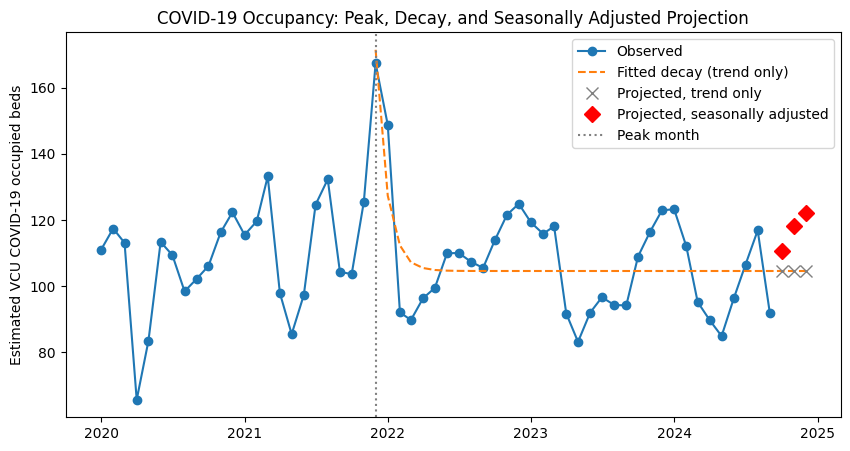

peak_month                 2021-12-01 00:00:00
peak_value                          167.283462
fitted_floor                        104.592643
fitted_amplitude                     66.800341
fitted_rate_per_month                 1.078188
last_observed_month        2024-09-01 00:00:00
last_observed_value                  91.850056
october_seasonal_index                1.057988
november_seasonal_index               1.130248
december_seasonal_index               1.167014
dtype: object

,trend_only,seasonal_index,seasonally_adjusted
2024-10-01,104.592643,1.057988,110.657733
2024-11-01,104.592643,1.130248,118.215647
2024-12-01,104.592643,1.167014,122.061081


In [40]:
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit



covid_monthly_census = vcu_category_occupied_beds["covid_19"].dropna()

peak_month = covid_monthly_census.idxmax()

peak_value = covid_monthly_census.loc[peak_month]



post_peak = covid_monthly_census.loc[peak_month:]

months_since_peak = (

    (post_peak.index.year - peak_month.year) * 12

    + (post_peak.index.month - peak_month.month)

).to_numpy(dtype=float)





def decay_to_floor(t, floor, amplitude, rate):

    return floor + amplitude * np.exp(-rate * t)





fitted_params, _ = curve_fit(

    decay_to_floor,

    months_since_peak,

    post_peak.to_numpy(),

    p0=[post_peak.min(), peak_value - post_peak.min(), 0.1],

    bounds=([0, 0, 0], [peak_value, peak_value, 5]),

)

fitted_floor, fitted_amplitude, fitted_rate = fitted_params



# ASSUMPTION: seasonal index = median(observed/trend) per calendar month, renormalized to average 1.

trend_at_observations = decay_to_floor(months_since_peak, *fitted_params)

seasonal_ratio = post_peak.to_numpy() / trend_at_observations

seasonal_index_raw = (

    pd.Series(seasonal_ratio, index=post_peak.index.month)

    .groupby(level=0)

    .median()

    .reindex(range(1, 13))

    .fillna(1.0)

)

seasonal_index = seasonal_index_raw / seasonal_index_raw.mean()



projection_months = pd.date_range("2024-10-01", "2024-12-01", freq="MS")

projection_offsets = (

    (projection_months.year - peak_month.year) * 12

    + (projection_months.month - peak_month.month)

).to_numpy(dtype=float)

projection_trend = decay_to_floor(projection_offsets, *fitted_params)

projection_seasonal_index = seasonal_index.loc[projection_months.month].to_numpy()



covid_projected_census = pd.DataFrame({

    "trend_only": projection_trend,

    "seasonal_index": projection_seasonal_index,

    "seasonally_adjusted": projection_trend * projection_seasonal_index,

}, index=projection_months)



fit_curve_months = pd.date_range(peak_month, "2024-12-01", freq="MS")

fit_curve_offsets = (

    (fit_curve_months.year - peak_month.year) * 12

    + (fit_curve_months.month - peak_month.month)

).to_numpy(dtype=float)

fit_curve_values = decay_to_floor(fit_curve_offsets, *fitted_params)



fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(covid_monthly_census.index, covid_monthly_census.to_numpy(), "o-", label="Observed")

ax.plot(fit_curve_months, fit_curve_values, "--", label="Fitted decay (trend only)")

ax.plot(

    covid_projected_census.index,

    covid_projected_census["trend_only"],

    "x",

    color="gray",

    markersize=9,

    label="Projected, trend only",

)

ax.plot(

    covid_projected_census.index,

    covid_projected_census["seasonally_adjusted"],

    "D",

    color="red",

    markersize=8,

    label="Projected, seasonally adjusted",

)

ax.axvline(peak_month, color="gray", linestyle=":", label="Peak month")

ax.set_ylabel("Estimated VCU COVID-19 occupied beds")

ax.set_title("COVID-19 Occupancy: Peak, Decay, and Seasonally Adjusted Projection")

ax.legend()

plt.show()



decay_summary = pd.Series({

    "peak_month": peak_month,

    "peak_value": peak_value,

    "fitted_floor": fitted_floor,

    "fitted_amplitude": fitted_amplitude,

    "fitted_rate_per_month": fitted_rate,

    "last_observed_month": post_peak.index.max(),

    "last_observed_value": post_peak.iloc[-1],

    "october_seasonal_index": seasonal_index.loc[10],

    "november_seasonal_index": seasonal_index.loc[11],

    "december_seasonal_index": seasonal_index.loc[12],

})



display(decay_summary)

covid_projected_census


## Recalculating the Master Dataset with the Seasonally Adjusted COVID-19 Projection



The master dataset previously left October–December 2024 COVID-19 as `NaN`, with the other 7 non-ICU sections absorbing 100% of the non-ICU remainder for those 3 months. Now that we have a seasonally adjusted COVID-19 projection for those months, we fold it back in:



1. **Rebalance the monthly targets:** for Oct–Dec 2024 only, COVID-19's monthly target becomes the seasonally adjusted projection, and the other 6 non-ICU sections are scaled down proportionally so the 8 non-ICU sections plus ICU still sum to the already-validated total census for those months. ICU is unaffected.

2. **Impute COVID-19 LOS for the same 3 months** using the calendar-month seasonal median (the same method already used for influenza), restricted to the January 2020+ window so the pre-outbreak placeholder months are never involved.

3. **Regenerate COVID-19's daily LOS and turnover series** from the extended monthly series. Because both generators draw random numbers sequentially by month with a fixed seed, the January 2020–September 2024 portion is reproduced bit-for-bit; only the 3 new months are new.

4. **Rebuild the master table** from all 9 regenerated sections.



**ASSUMPTION:** rebalancing shrinks the other 6 sections proportionally (not ICU), which assumes the "missing" COVID-19 patients were previously spread evenly across those sections rather than concentrated in one.


In [41]:
projection_target_months = covid_projected_census.index

non_covid_sections = [

    "newborn", "delivery", "non_elective_via_ed", "non_elective_other",

    "elective", "influenza", "other_viral",

]



for month_start in projection_target_months:

    new_covid_value = covid_projected_census.loc[month_start, "seasonally_adjusted"]

    non_intensive_total = vcu_non_intensive_census.loc[month_start]

    scale_factor = 1 - (new_covid_value / non_intensive_total)

    vcu_category_occupied_beds.loc[month_start, non_covid_sections] *= scale_factor

    vcu_category_occupied_beds.loc[month_start, "covid_19"] = new_covid_value



rebalanced_total_check = (

    vcu_category_occupied_beds.loc[projection_target_months].sum(axis=1)

    - monthly_vcu_census.loc[projection_target_months]

).abs().max()



# ASSUMPTION: impute the Oct-Dec 2024 COVID LOS gap by calendar-month seasonal median,

# restricted to 2020+ so pre-outbreak placeholder months never enter the imputation.

covid_los_2020_plus = covid_los.loc["2020-01-01":].copy()

covid_los_2020_plus.loc[projection_target_months] = np.nan

covid_los_2020_plus_filled = generators.impute_monthly_seasonal_median(covid_los_2020_plus)

vcu_category_los.loc[projection_target_months, "covid_19"] = (

    covid_los_2020_plus_filled.loc[projection_target_months]

)



covid_seed_offset = list(vcu_category_los.columns).index("covid_19")

covid_daily_los_extended = generators.generate_daily_length_of_stay(

    monthly_means=vcu_category_los["covid_19"].dropna(),

    daily_cv=daily_settings["coefficient_of_variation"],

    persistence=daily_settings["persistence"],

    seed=daily_settings["seed"] + 100 + covid_seed_offset,

).set_index("date")["length_of_stay_days"]



historical_unchanged = np.allclose(

    covid_daily_los_extended.loc[:"2024-09-30"].to_numpy(),

    los_wide["avg_los_covid_19_days"].dropna().to_numpy(),

)

los_wide["avg_los_covid_19_days"] = covid_daily_los_extended.reindex(los_wide.index)



section_turnover_updated = {}

for seed_offset, section_name in enumerate(section_names):

    if section_name == "intensive":

        daily_los_series = pd.Series(

            vcu_average_los_days, index=vcu_daily_history["date"]

        )

        monthly_target = vcu_category_occupied_beds["intensive"].dropna()

    else:

        daily_los_series = los_wide[f"avg_los_{section_name}_days"].dropna()

        monthly_target = vcu_category_occupied_beds[section_name].dropna()



    section_turnover_updated[section_name] = generators.generate_daily_bed_turnover(

        daily_los=daily_los_series,

        monthly_target=monthly_target,

        seed=daily_settings["seed"] + 300 + seed_offset,

    ).set_index("date")

section_turnover = section_turnover_updated



section_occupied_wide = pd.DataFrame(

    {name: df["occupied_beds"] for name, df in section_turnover.items()}

).sort_index()

section_admissions_wide = pd.DataFrame(

    {name: df["admissions"] for name, df in section_turnover.items()}

).sort_index()

section_discharges_wide = pd.DataFrame(

    {name: df["expected_discharges"] for name, df in section_turnover.items()}

).sort_index()



total_occupied_beds = section_occupied_wide.sum(axis=1, skipna=True)

total_free_beds = vcu_staffed_beds - total_occupied_beds



vcu_master_daily = pd.DataFrame({

    "date": total_occupied_beds.index,

    "total_staffed_beds": vcu_staffed_beds,

    "total_occupied_beds": total_occupied_beds.to_numpy(),

    "total_free_beds": total_free_beds.to_numpy(),

}).set_index("date")

vcu_master_daily = (

    vcu_master_daily.join(section_occupied_wide.add_prefix("occupied_beds_"))

    .join(section_admissions_wide.add_prefix("admissions_"))

    .join(section_discharges_wide.add_prefix("expected_discharges_"))

    .join(los_wide)

    .reset_index()

)



recalculation_validation = pd.Series({

    "rebalanced_monthly_sum_error": rebalanced_total_check,

    "historical_covid_los_unchanged": historical_unchanged,

    "october_covid_los_days": vcu_category_los.loc["2024-10-01", "covid_19"],

    "november_covid_los_days": vcu_category_los.loc["2024-11-01", "covid_19"],

    "december_covid_los_days": vcu_category_los.loc["2024-12-01", "covid_19"],

    "covid_nan_rows_remaining": vcu_master_daily["occupied_beds_covid_19"].isna().sum(),

    "days_over_capacity": int((total_occupied_beds > vcu_staffed_beds).sum()),

    "minimum_total_free_beds": total_free_beds.min(),

})



display(recalculation_validation)

vcu_master_daily.tail(10)


rebalanced_monthly_sum_error        0.0
historical_covid_los_unchanged     True
october_covid_los_days             7.41
november_covid_los_days            8.95
december_covid_los_days           9.335
covid_nan_rows_remaining           1095
days_over_capacity                    0
minimum_total_free_beds           156.0
dtype: object

,date,total_staffed_beds,total_occupied_beds,total_free_beds,occupied_beds_newborn,occupied_beds_delivery,occupied_beds_non_elective_via_ed,occupied_beds_non_elective_other,occupied_beds_elective,occupied_beds_covid_19,...,expected_discharges_other_viral,expected_discharges_intensive,avg_los_newborn_days,avg_los_delivery_days,avg_los_non_elective_via_ed_days,avg_los_non_elective_other_days,avg_los_elective_days,avg_los_covid_19_days,avg_los_influenza_days,avg_los_other_viral_days
2912,2024-12-22,905,666.0,239.0,30,43,85,118,71,122.0,...,16.151455,10.670991,1.867145,2.769992,5.049804,6.875407,4.782395,9.826351,4.081338,5.354444
2913,2024-12-23,905,687.0,218.0,34,42,92,112,71,125.0,...,17.481755,10.726692,1.845322,2.703024,5.174176,7.008822,4.891118,9.626574,4.053203,5.224339
2914,2024-12-24,905,694.0,211.0,31,43,92,108,72,123.0,...,16.954521,11.450157,1.769444,2.712879,5.142750,7.107682,4.675201,9.395961,3.988698,5.417366
2915,2024-12-25,905,681.0,224.0,34,43,91,103,66,119.0,...,17.168172,12.559037,1.781521,2.691300,4.989624,6.879243,4.783308,9.288671,4.100925,5.352598
2916,2024-12-26,905,680.0,225.0,28,39,94,105,69,119.0,...,17.065266,12.125796,1.733625,2.669938,5.056168,7.130829,4.926591,9.229824,4.215874,5.433619
2917,2024-12-27,905,670.0,235.0,32,37,91,104,68,117.0,...,16.187448,12.104499,1.762349,2.729854,5.312885,6.604567,4.997763,9.297665,4.401340,5.600691
2918,2024-12-28,905,669.0,236.0,25,44,84,105,69,121.0,...,14.833870,12.425405,1.711133,2.695775,5.378012,6.376637,5.017509,9.089282,4.321754,5.829460
2919,2024-12-29,905,660.0,245.0,26,40,81,106,69,120.0,...,14.458168,12.691982,1.737417,2.661069,5.514712,6.638517,4.931751,8.950727,4.288941,5.784936
2920,2024-12-30,905,652.0,253.0,20,46,78,101,70,124.0,...,15.091948,12.574830,1.807256,2.743488,5.430422,6.857762,5.050756,9.209577,4.207711,5.842944
2921,2024-12-31,905,643.0,262.0,19,46,74,103,66,124.0,...,15.070771,11.461720,1.835213,2.744774,5.386256,6.702882,4.877434,8.881678,4.244012,5.778700


In [42]:
output_path = Path("data/vcu_master_daily.csv")

vcu_master_daily.to_csv(output_path, index=False)



export_validation = pd.Series({

    "output_path": str(output_path),

    "row_count": len(vcu_master_daily),

    "column_count": vcu_master_daily.shape[1],

    "date_min": vcu_master_daily["date"].min(),

    "date_max": vcu_master_daily["date"].max(),

    "file_size_kb": round(output_path.stat().st_size / 1024, 1),

})



export_validation


output_path     data\vcu_master_daily.csv
row_count                            2922
column_count                           39
date_min              2017-01-01 00:00:00
date_max              2024-12-31 00:00:00
file_size_kb                       1097.5
dtype: object

## Checking December 2024 Against Historical November-to-December Changes



To test whether the December 2024 drop is a genuine decline or a likely data-entry issue, we compare every November→December change (both raw and percentage) across 2017–2024 for the statewide total and intensive series. If 2024's change falls far outside the range set by 2017–2023, that supports treating it as an anomaly rather than a real decline.


## Correcting December 2024 as a Data-Entry Issue



Every other year's November→December change is flat-to-positive (statewide: -0.96% to +3.09%; intensive: +0.06% to +8.95%). December 2024 shows -16.15% and -27.41%, with z-scores of roughly -12 relative to the other 7 years — far beyond anything explainable as normal variation. This is treated as a data-entry issue, not a real decline.



**Correction:** replace December 2024 with November 2024 scaled by the historical average November→December growth rate (2017–2023), for both the statewide and intensive series. The original raw arrays are left untouched; a corrected series is used for all downstream modeling instead.


In [ ]:
mean_statewide_pct_change = history["statewide_pct_change"].mean()

mean_intensive_pct_change = history["intensive_pct_change"].mean()



nov_2024 = pd.Timestamp(2024, 11, 1)

dec_2024 = pd.Timestamp(2024, 12, 1)



corrected_statewide_series = statewide_series.copy()

corrected_statewide_series.loc[dec_2024] = (

    statewide_series.loc[nov_2024] * (1 + mean_statewide_pct_change)

)



corrected_intensive_series = intensive_series.copy()

corrected_intensive_series.loc[dec_2024] = (

    intensive_series.loc[nov_2024] * (1 + mean_intensive_pct_change)

)



correction_summary = pd.Series({

    "mean_historical_statewide_pct_change": mean_statewide_pct_change,

    "original_dec_2024_statewide": statewide_series.loc[dec_2024],

    "corrected_dec_2024_statewide": corrected_statewide_series.loc[dec_2024],

    "mean_historical_intensive_pct_change": mean_intensive_pct_change,

    "original_dec_2024_intensive": intensive_series.loc[dec_2024],

    "corrected_dec_2024_intensive": corrected_intensive_series.loc[dec_2024],

})



correction_summary


mean_historical_statewide_pct_change        0.012438
original_dec_2024_statewide             10037.000000
corrected_dec_2024_statewide            12118.884304
mean_historical_intensive_pct_change        0.039314
original_dec_2024_intensive               903.000000
corrected_dec_2024_intensive             1292.906508
dtype: float64

In [ ]:
statewide_series = pd.Series(

    np.asarray(Average_number_of_occupied_beds_per_day, dtype=float),

    index=pd.to_datetime(Dates_of_data),

)

intensive_series = pd.Series(

    np.asarray(average_daily_number_of_intesnive_beds, dtype=float),

    index=pd.to_datetime(Dates_of_data),

)



years = range(2017, 2025)

nov_dec_rows = []

for year in years:

    nov = pd.Timestamp(year, 11, 1)

    dec = pd.Timestamp(year, 12, 1)

    nov_dec_rows.append({

        "year": year,

        "statewide_nov": statewide_series.loc[nov],

        "statewide_dec": statewide_series.loc[dec],

        "statewide_change": statewide_series.loc[dec] - statewide_series.loc[nov],

        "statewide_pct_change": statewide_series.loc[dec] / statewide_series.loc[nov] - 1,

        "intensive_nov": intensive_series.loc[nov],

        "intensive_dec": intensive_series.loc[dec],

        "intensive_change": intensive_series.loc[dec] - intensive_series.loc[nov],

        "intensive_pct_change": intensive_series.loc[dec] / intensive_series.loc[nov] - 1,

    })



nov_dec_comparison = pd.DataFrame(nov_dec_rows).set_index("year")



history = nov_dec_comparison.drop(index=2024)

stats_2024 = nov_dec_comparison.loc[2024]





def flag_outlier(value, series):

    mean, std = series.mean(), series.std(ddof=0)

    z_score = (value - mean) / std if std > 0 else np.nan

    is_outside_historical_range = value < series.min() or value > series.max()

    return z_score, is_outside_historical_range





statewide_z, statewide_outside_range = flag_outlier(

    stats_2024["statewide_pct_change"], history["statewide_pct_change"]

)

intensive_z, intensive_outside_range = flag_outlier(

    stats_2024["intensive_pct_change"], history["intensive_pct_change"]

)



outlier_summary = pd.Series({

    "historical_statewide_pct_change_min": history["statewide_pct_change"].min(),

    "historical_statewide_pct_change_max": history["statewide_pct_change"].max(),

    "2024_statewide_pct_change": stats_2024["statewide_pct_change"],

    "2024_statewide_z_score": statewide_z,

    "2024_statewide_outside_historical_range": statewide_outside_range,

    "historical_intensive_pct_change_min": history["intensive_pct_change"].min(),

    "historical_intensive_pct_change_max": history["intensive_pct_change"].max(),

    "2024_intensive_pct_change": stats_2024["intensive_pct_change"],

    "2024_intensive_z_score": intensive_z,

    "2024_intensive_outside_historical_range": intensive_outside_range,

})



display(nov_dec_comparison.round(4))

outlier_summary


,statewide_nov,statewide_dec,statewide_change,statewide_pct_change,intensive_nov,intensive_dec,intensive_change,intensive_pct_change
year,,,,,,,,
2017,11380.0,11271.0,-109.0,-0.0096,1579.0,1580.0,1.0,0.0006
2018,11492.0,11436.0,-56.0,-0.0049,1661.0,1699.0,38.0,0.0229
2019,11617.0,11835.0,218.0,0.0188,1662.0,1720.0,58.0,0.0349
2020,11745.0,12108.0,363.0,0.0309,1654.0,1802.0,148.0,0.0895
2021,12206.0,12473.0,267.0,0.0219,1706.0,1812.0,106.0,0.0621
2022,12183.0,12252.0,69.0,0.0057,1348.0,1368.0,20.0,0.0148
2023,12383.0,12684.0,301.0,0.0243,1331.0,1398.0,67.0,0.0503
2024,11970.0,10037.0,-1933.0,-0.1615,1244.0,903.0,-341.0,-0.2741


historical_statewide_pct_change_min        -0.009578
historical_statewide_pct_change_max         0.030907
2024_statewide_pct_change                  -0.161487
2024_statewide_z_score                    -12.120709
2024_statewide_outside_historical_range         True
historical_intensive_pct_change_min         0.000633
historical_intensive_pct_change_max          0.08948
2024_intensive_pct_change                  -0.274116
2024_intensive_z_score                    -11.137358
2024_intensive_outside_historical_range         True
dtype: object